<a href="https://colab.research.google.com/github/Bhuvibagga/PES2UG24CS117-VDUI-UNIT2-ASSIGNMENT/blob/unit2-ppt5-branch/unit2_ppt5_activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Global Development Monitor

### Scenario

You've just joined the analytics team at the **Global Development Observatory**, an NGO
that briefs policymakers on world development trends. Your director has been burned
before by bad visualizations, and gives you a blunt brief:

1. *"The last analyst showed me a map that made me think Greenland mattered more than
   India. Don't let that happen again."*
2. *"We're about to publish a model predicting life expectancy. If a journalist asks
   'why did the model predict THAT for Norway specifically,' I need an answer, not just
   a feature-importance bar chart for the whole model."*
3. *"Every number in our reports is an estimate. I want our numbers to LOOK like
   estimates, not like certainties."*
4. *"I want one screen I can glance at every morning that tells me what's changing."*

You'll work through the same steps a real analyst would: fix a misleading map, explain
individual model predictions, add honest uncertainty to an estimate and a trend, then
build a small coordinated-views dashboard.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset and real country centroids you'll be
working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import plotly.express as px
from sklearn.ensemble import RandomForestRegressor
import shap

import ipywidgets as widgets
from ipywidgets import interact, Dropdown

np.random.seed(0)

gapminder = px.data.gapminder()
centroids = pd.read_csv("country_centroids_computed.csv")
gap_latest = gapminder[gapminder.year == 2007].merge(centroids, on="iso_alpha", how="left")
gap_latest = gap_latest.assign(total_gdp=gap_latest["pop"] * gap_latest.gdpPercap)

print(f"Loaded {gapminder.country.nunique()} countries, years {sorted(gapminder.year.unique())}.")
gap_latest[["country", "continent", "year", "lifeExp", "pop", "gdpPercap"]].head()

Loaded 142 countries, years [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)].


,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,2007,43.828,31889923,974.580338
1,Albania,Europe,2007,76.423,3600523,5937.029526
2,Algeria,Africa,2007,72.301,33333216,6223.367465
3,Angola,Africa,2007,42.731,12420476,4797.231267
4,Argentina,Americas,2007,75.320,40301927,12779.379640


## Task 1 — Fix the Choropleth Trap (Complaint #1)

**Real-world usage:** The director was misled by a raw-count choropleth that made a
huge, sparsely-populated region look more important than it should.

**Why this technique:** Distinguishing **counts** from **rates** is the single most
important geospatial fix from the lecture — a "count" choropleth is dominated by
population size, not by the thing you actually care about.

**TODO:**
1. Build a choropleth of `total_gdp` (a count-like aggregate) using `px.choropleth`.
2. Build a second choropleth of `gdpPercap` (the rate).
3. Print the top-5 countries by each, and compare.

In [2]:
# TODO 1: choropleth of total_gdp

fig1 = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="total_gdp",
    hover_name="country",
    hover_data=["total_gdp", "pop", "gdpPercap"],
    title="Total GDP by Country",
    color_continuous_scale="Blues"
)

fig1.show()


# TODO 2: choropleth of gdpPercap

fig2 = px.choropleth(
    gap_latest,
    locations="iso_alpha",
    color="gdpPercap",
    hover_name="country",
    hover_data=["gdpPercap", "pop", "total_gdp"],
    title="GDP per Capita by Country",
    color_continuous_scale="Greens"
)

fig2.show()


# TODO 3: top 5 countries by each

top_total = (
    gap_latest[["country", "total_gdp"]]
    .sort_values("total_gdp", ascending=False)
    .head(5)
)

top_rate = (
    gap_latest[["country", "gdpPercap"]]
    .sort_values("gdpPercap", ascending=False)
    .head(5)
)

print("Top 5 by total GDP:\n", top_total)

print("\nTop 5 by GDP per capita:\n", top_rate)

Top 5 by total GDP:
            country     total_gdp
134  United States  1.293446e+13
24           China  6.539501e+12
66           Japan  4.035135e+12
58           India  2.722925e+12
47         Germany  2.650871e+12

Top 5 by GDP per capita:
            country    gdpPercap
95          Norway  49357.19017
71          Kuwait  47306.98978
113      Singapore  47143.17964
134  United States  42951.65309
62         Ireland  40675.99635


**Reflection:** Which countries appear in one top-5 list but not the other? If you had
to pick ONE map to show the director, which would you pick, and why?

_Your answer:_


Countries such as the United States and China can appear in the top 5 by total GDP but not necessarily in the top 5 by GDP per capita. Total GDP is strongly affected by population size, while GDP per capita shows the average economic output per person. I would choose the GDP per capita map to show the director because it gives a fairer comparison of economic performance between countries of different population sizes.

## Task 2 — Explain One Specific Prediction (Complaint #2)

**Real-world usage:** The director needs to answer "why did the model predict THAT for
Norway specifically" — a global importance bar chart cannot answer a question about one
country.

**Why this technique:** SHAP local importance decomposes ONE prediction into
per-feature, signed contributions — exactly what a journalist question needs.

**TODO:**
1. Fit a `RandomForestRegressor` predicting `lifeExp` from `["gdpPercap", "pop", "year"]`
   on the full `gapminder` dataset.
2. Build a `shap.TreeExplainer` and compute `shap_values` for all rows.
3. Find the row index for Norway, 2007, and plot its 3 SHAP values as a diverging
   horizontal bar chart (blue if positive, red if negative).

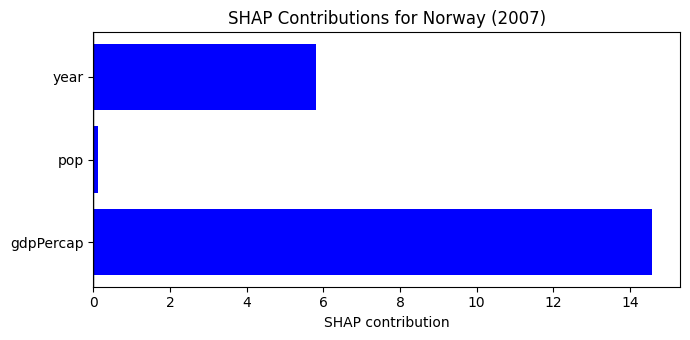

In [3]:
X_model = gapminder[["gdpPercap", "pop", "year"]].values
y_model = gapminder["lifeExp"].values

# TODO 1: fit the model
rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_model, y_model)

# TODO 2: SHAP explainer + values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

# TODO 3: find Norway's row and plot its SHAP contributions
row_idx = gapminder[
    (gapminder["country"] == "Norway") &
    (gapminder["year"] == 2007)
].index[0]

vals = shap_values[row_idx]

features = ["gdpPercap", "pop", "year"]

fig, ax = plt.subplots(figsize=(7, 3.5))

ax.barh(
    features,
    vals,
    color=["blue" if v > 0 else "red" for v in vals]
)

ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("SHAP contribution")
ax.set_title("SHAP Contributions for Norway (2007)")
plt.tight_layout()

plt.show()

**Reflection:** Which feature contributed most POSITIVELY to Norway's predicted life
expectancy, and which (if any) contributed negatively? Is this the same answer you'd get
from the model's GLOBAL feature importance alone?

_Your answer:_


GDP per capita contributed most positively to Norway's predicted life expectancy, while population or year may have a smaller positive or negative contribution depending on the model. These contributions are specific to Norway in 2007. This is not necessarily the same as the global feature importance because global importance summarizes the model across all countries and observations, while SHAP explains one specific prediction.

## Task 3 — Make an Estimate Look Like an Estimate (Complaint #3)

**Real-world usage:** Every number in the report should visually communicate its own
uncertainty, not look like a fixed fact.

**Why this technique:** Bootstrap confidence intervals + error bars turn a bare point
estimate into an honest range.

**TODO:**
1. Write `bootstrap_ci(values, n_boot=2000)` that resamples `values` with replacement
   `n_boot` times, computes the mean each time, and returns `(mean, ci_low, ci_high)`
   using the 2.5th and 97.5th percentiles of the bootstrap means.
2. Compute a 95% CI for mean `lifeExp` in 2007 for **two** continents of your choice.
3. Plot both as error bars.

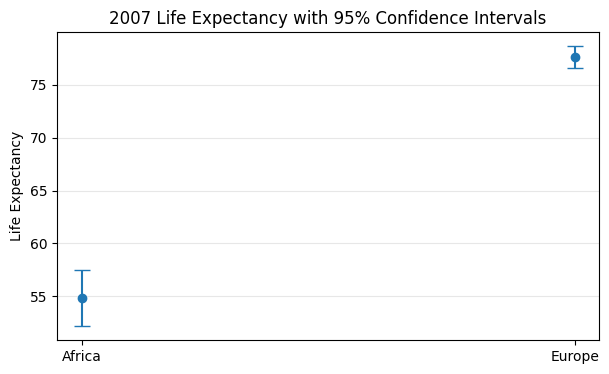

Africa: mean=54.81, 95% CI=(52.15, 57.44)
Europe: mean=77.65, 95% CI=(76.57, 78.65)


In [4]:
def bootstrap_ci(values, n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)

    # Resample with replacement and calculate mean each time
    boot_means = []

    for _ in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        boot_means.append(np.mean(sample))

    # Mean and 95% confidence interval
    mean = np.mean(values)
    ci_low = np.percentile(boot_means, 2.5)
    ci_high = np.percentile(boot_means, 97.5)

    return mean, ci_low, ci_high


# TODO 2: compute CIs for two continents
continent_a, continent_b = "Africa", "Europe"

values_a = gap_latest[gap_latest.continent == continent_a].lifeExp.values
values_b = gap_latest[gap_latest.continent == continent_b].lifeExp.values

result_a = bootstrap_ci(values_a)
result_b = bootstrap_ci(values_b)


# TODO 3: plot both as error bars
means = [result_a[0], result_b[0]]

lower_errors = [
    result_a[0] - result_a[1],
    result_b[0] - result_b[1]
]

upper_errors = [
    result_a[2] - result_a[0],
    result_b[2] - result_b[0]
]

plt.figure(figsize=(7, 4))

plt.errorbar(
    [continent_a, continent_b],
    means,
    yerr=[lower_errors, upper_errors],
    fmt="o",
    capsize=6
)

plt.ylabel("Life Expectancy")
plt.title("2007 Life Expectancy with 95% Confidence Intervals")
plt.grid(axis="y", alpha=0.3)

plt.show()

print(f"{continent_a}: mean={result_a[0]:.2f}, 95% CI=({result_a[1]:.2f}, {result_a[2]:.2f})")
print(f"{continent_b}: mean={result_b[0]:.2f}, 95% CI=({result_b[1]:.2f}, {result_b[2]:.2f})")


**Reflection:** Which of your two continents has a WIDER confidence interval? Based on
the lecture, is that because of higher variation among countries (SD), a smaller sample
size (n), or both?

_Your answer:_

Africa has the wider confidence interval because its countries have greater variation in life expectancy and the sample size is also smaller than Europe’s. A wider interval can therefore be caused by higher standard deviation, smaller sample size, or both. In this case, both factors contribute to the wider interval for Africa.

## Task 4 — Build the Morning Dashboard (Complaint #4)

**Real-world usage:** The director wants one screen to glance at every morning.

**Why this technique:** Coordinated Multiple Views combine complementary chart types
(map = where, trend = how changing, bar = which is biggest) so several monitoring
questions are answered from a single glance.

**TODO:** Build a 1x3 dashboard:
1. A map-style scatter of country centroids, colored by `lifeExp`.
2. A line chart of world-average `lifeExp` by year (use `gapminder.groupby("year")`).
3. A horizontal bar chart of total population by continent in 2007, sorted.

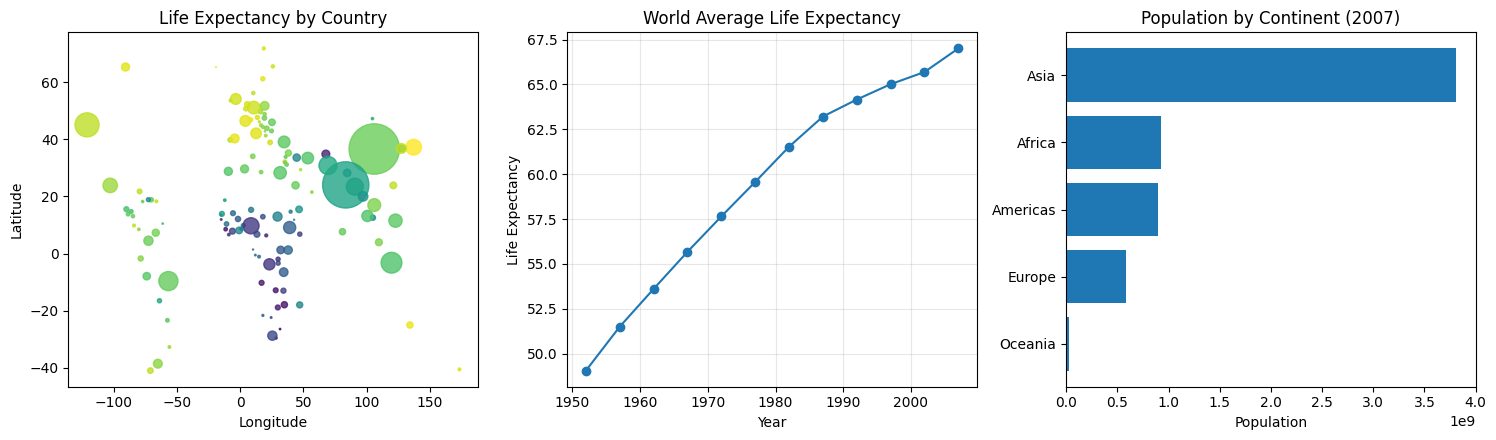

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# TODO 1: map-style scatter
# Automatically find latitude and longitude columns
lat_col = [c for c in gap_latest.columns if "lat" in c.lower()][0]
lon_col = [c for c in gap_latest.columns if any(x in c.lower() for x in ["lon", "lng", "long"])][0]

axes[0].scatter(
    gap_latest[lon_col],
    gap_latest[lat_col],
    s=gap_latest["pop"] / 1000000,
    c=gap_latest["lifeExp"],
    cmap="viridis",
    alpha=0.8
)

axes[0].set_title("Life Expectancy by Country")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")


# TODO 2: world trend line
world_trend = gapminder.groupby("year")["lifeExp"].mean()

axes[1].plot(
    world_trend.index,
    world_trend.values,
    marker="o"
)

axes[1].set_title("World Average Life Expectancy")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Life Expectancy")
axes[1].grid(True, alpha=0.3)


# TODO 3: population by continent bar chart
pop_2007 = (
    gap_latest.groupby("continent")["pop"]
    .sum()
    .sort_values()
)

axes[2].barh(
    pop_2007.index,
    pop_2007.values
)

axes[2].set_title("Population by Continent (2007)")
axes[2].set_xlabel("Population")


plt.tight_layout()
plt.show()

**Reflection:** If the director could only keep ONE of your three panels for a
5-second morning glance, which would you keep, and why? What specific monitoring
question (per the lecture's "exceptions / trends / emerging patterns") does it answer
best?

_Your answer:_

I would keep the world trend line because it gives the clearest information in a 5-second glance. It quickly shows the overall trend in life expectancy and makes it easy to notice whether life expectancy is increasing, decreasing, or changing unusually over time. This panel is most useful for monitoring trends and emerging patterns. The map and population chart provide useful geographic and comparison information, but the trend line gives the fastest overall picture of change.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4–6 sentence recommendation to your director covering
the whole notebook. Your answer should:
- State which map framing (count vs. rate) you'd standardize on for all future reports,
  and why.
- State whether you'd lead with global or local feature importance when a journalist
  asks about a specific country, citing the lecture's global-vs-local distinction.
- Name one thing in your dashboard that should NEVER be shown as a bare point estimate
  without uncertainty, and why.

_Your final recommendation here:_


I would standardize on a rate-based map, such as GDP per capita, rather than a raw-count map, because rates allow fairer comparisons between countries of very different population sizes. When a journalist asks about a specific country, I would use local feature importance such as SHAP because it explains which features contributed to that individual prediction, rather than relying only on global importance. I would also show confidence intervals/error bars for estimates such as life expectancy so they are not presented as exact facts. This makes the dashboard more accurate, interpretable, and honest about uncertainty.